**# DATASET 01 — Parkinson's Disease Data (Voice Measurements)**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# ===== LOAD DATASET =====
print('='*80)
print('DATASET 01: PARKINSON\'S DISEASE VOICE DATA')
print('='*80)

df = pd.read_csv('/content/sample_data/Day14_Parkinsons_Disease_Data.csv')

print(f'Dataset shape: {df.shape}')
print(f'\nFirst 5 rows:')
print(df.head())

DATASET 01: PARKINSON'S DISEASE VOICE DATA
Dataset shape: (195, 24)

First 5 rows:
             name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0  phon_R01_S01_1      119.992       157.302        74.997         0.00784   
1  phon_R01_S01_2      122.400       148.650       113.819         0.00968   
2  phon_R01_S01_3      116.682       131.111       111.555         0.01050   
3  phon_R01_S01_4      116.676       137.871       111.366         0.00997   
4  phon_R01_S01_5      116.014       141.781       110.655         0.01284   

   MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  ...  \
0           0.00007   0.00370   0.00554     0.01109       0.04374  ...   
1           0.00008   0.00465   0.00696     0.01394       0.06134  ...   
2           0.00009   0.00544   0.00781     0.01633       0.05233  ...   
3           0.00009   0.00502   0.00698     0.01505       0.05492  ...   
4           0.00011   0.00655   0.00908     0.01966       0.06425  ...   

   

In [9]:
# ===== STEP 1: CONVERT CATEGORICAL TO NUMERICAL =====
print('='*80)
print('STEP 1: CHECKING AND CONVERTING CATEGORICAL FEATURES')
print('='*80)

categorical_cols = df.select_dtypes(include=['object']).columns
print(f'Categorical columns found: {categorical_cols.tolist()}')

# Drop identifier column
if 'name' in df.columns:
    df = df.drop('name', axis=1)
    print('Dropped name column (identifier, not useful for modeling)')

print(f'\nData types after processing:')
print(df.dtypes)

STEP 1: CHECKING AND CONVERTING CATEGORICAL FEATURES
Categorical columns found: ['name']
Dropped name column (identifier, not useful for modeling)

Data types after processing:
MDVP:Fo(Hz)         float64
MDVP:Fhi(Hz)        float64
MDVP:Flo(Hz)        float64
MDVP:Jitter(%)      float64
MDVP:Jitter(Abs)    float64
MDVP:RAP            float64
MDVP:PPQ            float64
Jitter:DDP          float64
MDVP:Shimmer        float64
MDVP:Shimmer(dB)    float64
Shimmer:APQ3        float64
Shimmer:APQ5        float64
MDVP:APQ            float64
Shimmer:DDA         float64
NHR                 float64
HNR                 float64
status                int64
RPDE                float64
DFA                 float64
spread1             float64
spread2             float64
D2                  float64
PPE                 float64
dtype: object


In [11]:
# ===== STEP 2: HANDLE MISSING VALUES =====
print('='*80)
print('STEP 2: HANDLING MISSING VALUES')
print('='*80)

null_counts = df.isnull().sum()
null_cols = null_counts[null_counts > 0]

if len(null_cols) > 0:
    print(f'Columns with null values:\n{null_cols}')
    for col in null_cols.index:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f'  Replaced nulls in {col} with median: {median_val:.4f}')
else:
    print('No null values found in the dataset')

STEP 2: HANDLING MISSING VALUES
No null values found in the dataset


In [12]:
# ===== STEP 3: SEPARATE FEATURES AND TARGET =====
print('='*80)
print('STEP 3: SEPARATING FEATURES AND TARGET')
print('='*80)

features = df.drop('status', axis=1)
target = df['status']

print(f'Features shape: {features.shape}')
print(f'Target shape: {target.shape}')

# Class imbalance check
healthy = (target == 0).sum()
parkinsons = (target == 1).sum()
total = len(target)
print(f'\nClass Distribution:')
print(f'  Healthy (0):     {healthy} samples ({healthy/total*100:.1f}%)')
print(f'  Parkinsons (1):  {parkinsons} samples ({parkinsons/total*100:.1f}%)')
if parkinsons/total > 0.65 or healthy/total > 0.65:
    print('  WARNING: Class imbalance detected. Do NOT use accuracy as your only metric.')
    print('  Use: precision, recall, F1-score, and AUC-ROC instead.')
    print('  Consider: class_weight=balanced in your model, or SMOTE for oversampling.')

STEP 3: SEPARATING FEATURES AND TARGET
Features shape: (195, 22)
Target shape: (195,)

Class Distribution:
  Healthy (0):     48 samples (24.6%)
  Parkinsons (1):  147 samples (75.4%)
  Use: precision, recall, F1-score, and AUC-ROC instead.
  Consider: class_weight=balanced in your model, or SMOTE for oversampling.


In [18]:
# ===== STEP 4: TRAIN/TEST SPLIT — MUST HAPPEN BEFORE SCALING =====
print('='*80)
print('STEP 4: TRAIN/TEST SPLIT (BEFORE ANY SCALING)')
print('='*80)
print('Reason: Scaler must only learn from training data.')
print('If we scale first, the scaler sees test data — this is data leakage.')
print()

X_train, X_test, y_train, y_test = train_test_split(
    features, target,
    test_size=0.2,
    random_state=42,
    stratify=target  # keeps class ratio same in both splits
)

print(f'Training set:   {X_train.shape[0]} samples')
print(f'Test set:       {X_test.shape[0]} samples')
print(f'\nClass distribution in training set:')
print(f'  Healthy: {(y_train==0).sum()}  |  Parkinsons: {(y_train==1).sum()}')
print(f'Class distribution in test set:')
print(f'  Healthy: {(y_test==0).sum()}  |  Parkinsons: {(y_test==1).sum()}')

STEP 4: TRAIN/TEST SPLIT (BEFORE ANY SCALING)
Reason: Scaler must only learn from training data.
If we scale first, the scaler sees test data — this is data leakage.

Training set:   156 samples
Test set:       39 samples

Class distribution in training set:
  Healthy: 38  |  Parkinsons: 118
Class distribution in test set:
  Healthy: 10  |  Parkinsons: 29


STEP 5: VISUALIZING OUTLIERS (BEFORE TREATMENT)


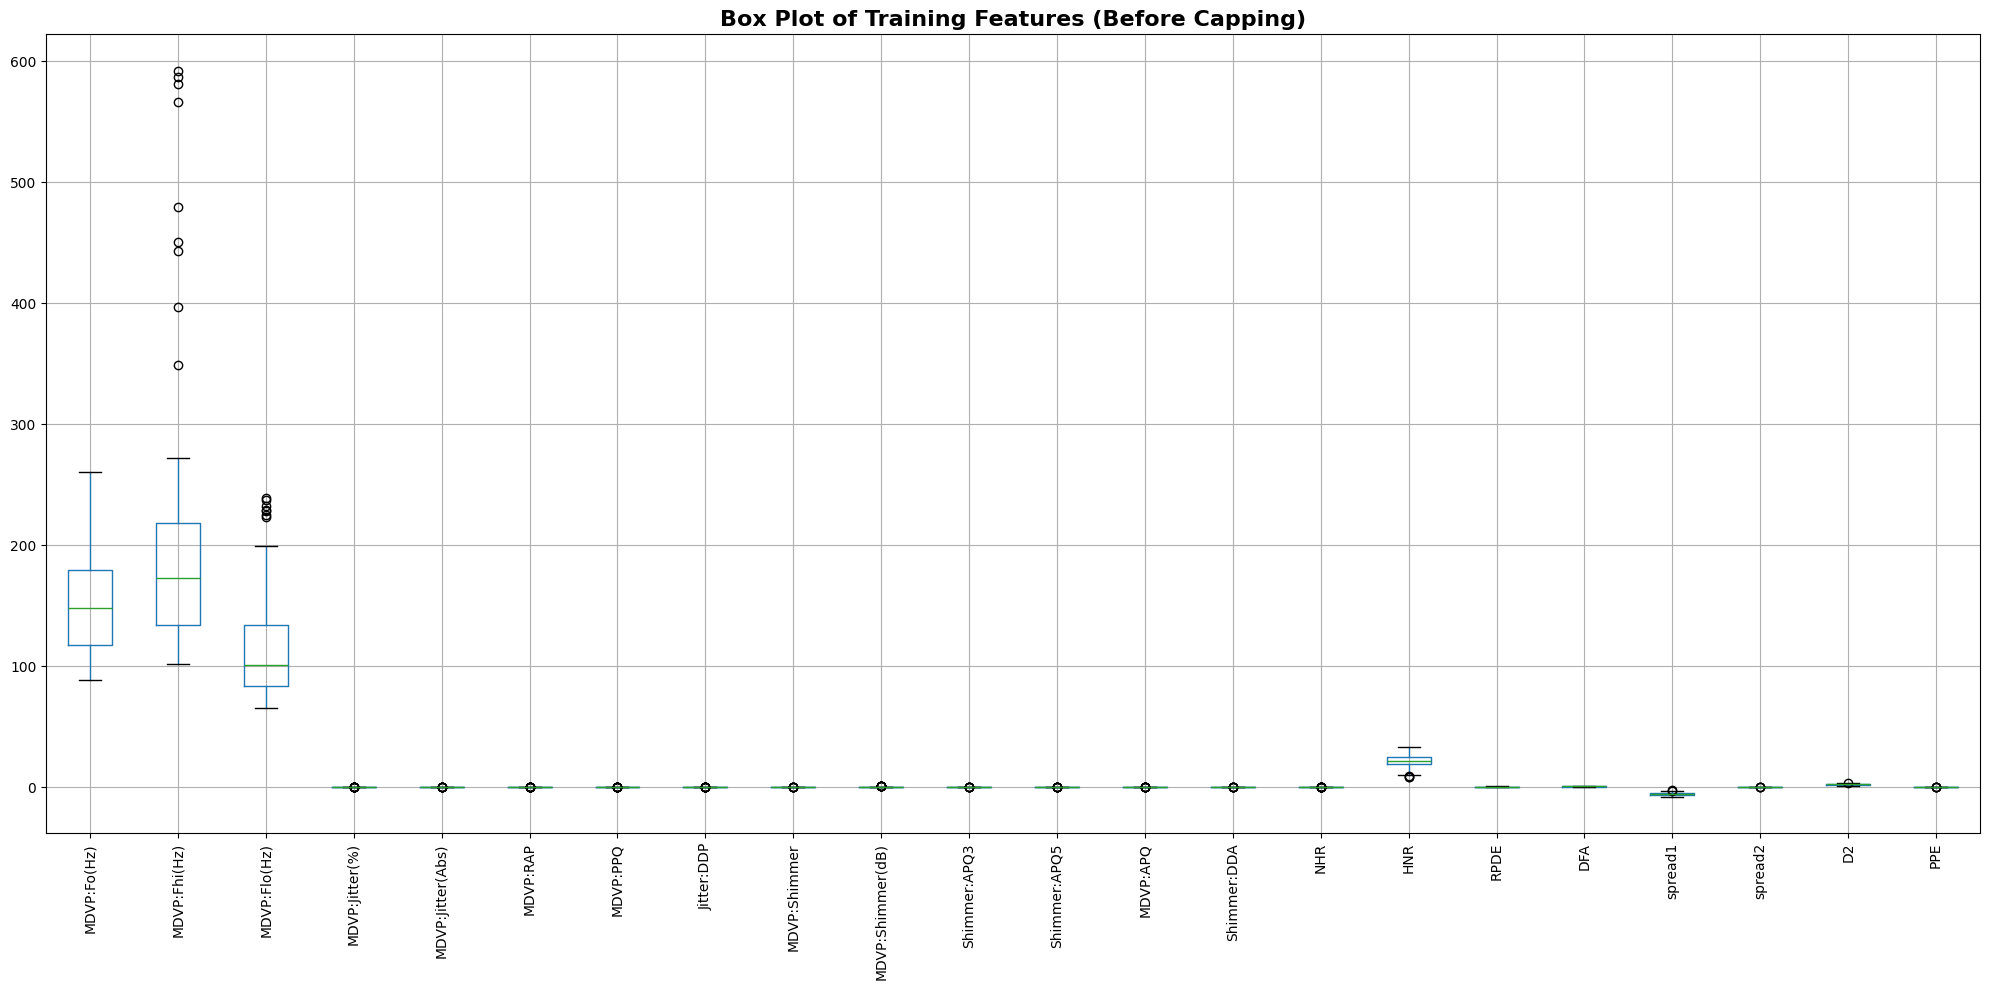

Saved: ds1_boxplot_before.png


In [19]:
# ===== STEP 5: VISUALIZE OUTLIERS BEFORE TREATMENT =====
print('='*80)
print('STEP 5: VISUALIZING OUTLIERS (BEFORE TREATMENT)')
print('='*80)

plt.figure(figsize=(20, 10))
X_train.boxplot(rot=90)
plt.title('Box Plot of Training Features (Before Capping)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('ds1_boxplot_before.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ds1_boxplot_before.png')

In [20]:
# ===== STEP 6: DETECT OUTLIER FEATURES =====
print('='*80)
print('STEP 6: DETECTING OUTLIER FEATURES USING IQR')
print('='*80)

def identify_outlier_features(dataframe, threshold=1.5):
    """Identify features that have outliers using IQR method.
    Always run this on TRAINING data only."""
    features_with_outliers = []
    for col in dataframe.columns:
        if dataframe[col].dtype in ['int64', 'float64']:
            Q1 = dataframe[col].quantile(0.25)
            Q3 = dataframe[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - threshold * IQR
            upper = Q3 + threshold * IQR
            outlier_count = ((dataframe[col] < lower) | (dataframe[col] > upper)).sum()
            if outlier_count > 0:
                features_with_outliers.append((col, outlier_count))
    return [col for col, _ in features_with_outliers]

# Detect on training data only
outlier_features = identify_outlier_features(X_train)
print(f'Features with outliers: {len(outlier_features)}')
print(outlier_features)

STEP 6: DETECTING OUTLIER FEATURES USING IQR
Features with outliers: 19
['MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'spread1', 'spread2', 'D2', 'PPE']


In [21]:
# ===== STEP 7: CAP OUTLIERS (WINSORIZATION) =====
print('='*80)
print('STEP 7: CAPPING OUTLIERS AT 1st/99th PERCENTILE (WINSORIZATION)')
print('='*80)
print(' Capping limits extreme values while keeping the patient in the dataset.')
print()

def cap_outliers(train_df, test_df, columns, lower_pct=1, upper_pct=99):
    """Cap outliers using percentiles calculated from training data only.
    Same caps are then applied to test data — no leakage."""
    train_capped = train_df.copy()
    test_capped = test_df.copy()
    cap_values = {}

    for col in columns:
        # Learn caps from training data only
        lower = train_df[col].quantile(lower_pct / 100)
        upper = train_df[col].quantile(upper_pct / 100)
        cap_values[col] = (lower, upper)

        # Apply same caps to both train and test
        train_capped[col] = train_df[col].clip(lower, upper)
        test_capped[col] = test_df[col].clip(lower, upper)

    return train_capped, test_capped, cap_values

X_train_capped, X_test_capped, cap_values = cap_outliers(
    X_train, X_test, outlier_features
)

print(f'Capping applied to {len(outlier_features)} features')
print('Sample cap values (first 5 features):')
for col in outlier_features[:5]:
    low, high = cap_values[col]
    print(f'  {col}: [{low:.4f}, {high:.4f}]')

STEP 7: CAPPING OUTLIERS AT 1st/99th PERCENTILE (WINSORIZATION)
 Capping limits extreme values while keeping the patient in the dataset.

Capping applied to 19 features
Sample cap values (first 5 features):
  MDVP:Fhi(Hz): [108.2370, 583.6641]
  MDVP:Flo(Hz): [65.7676, 234.6256]
  MDVP:Jitter(%): [0.0018, 0.0305]
  MDVP:Jitter(Abs): [0.0000, 0.0002]
  MDVP:RAP: [0.0008, 0.0182]


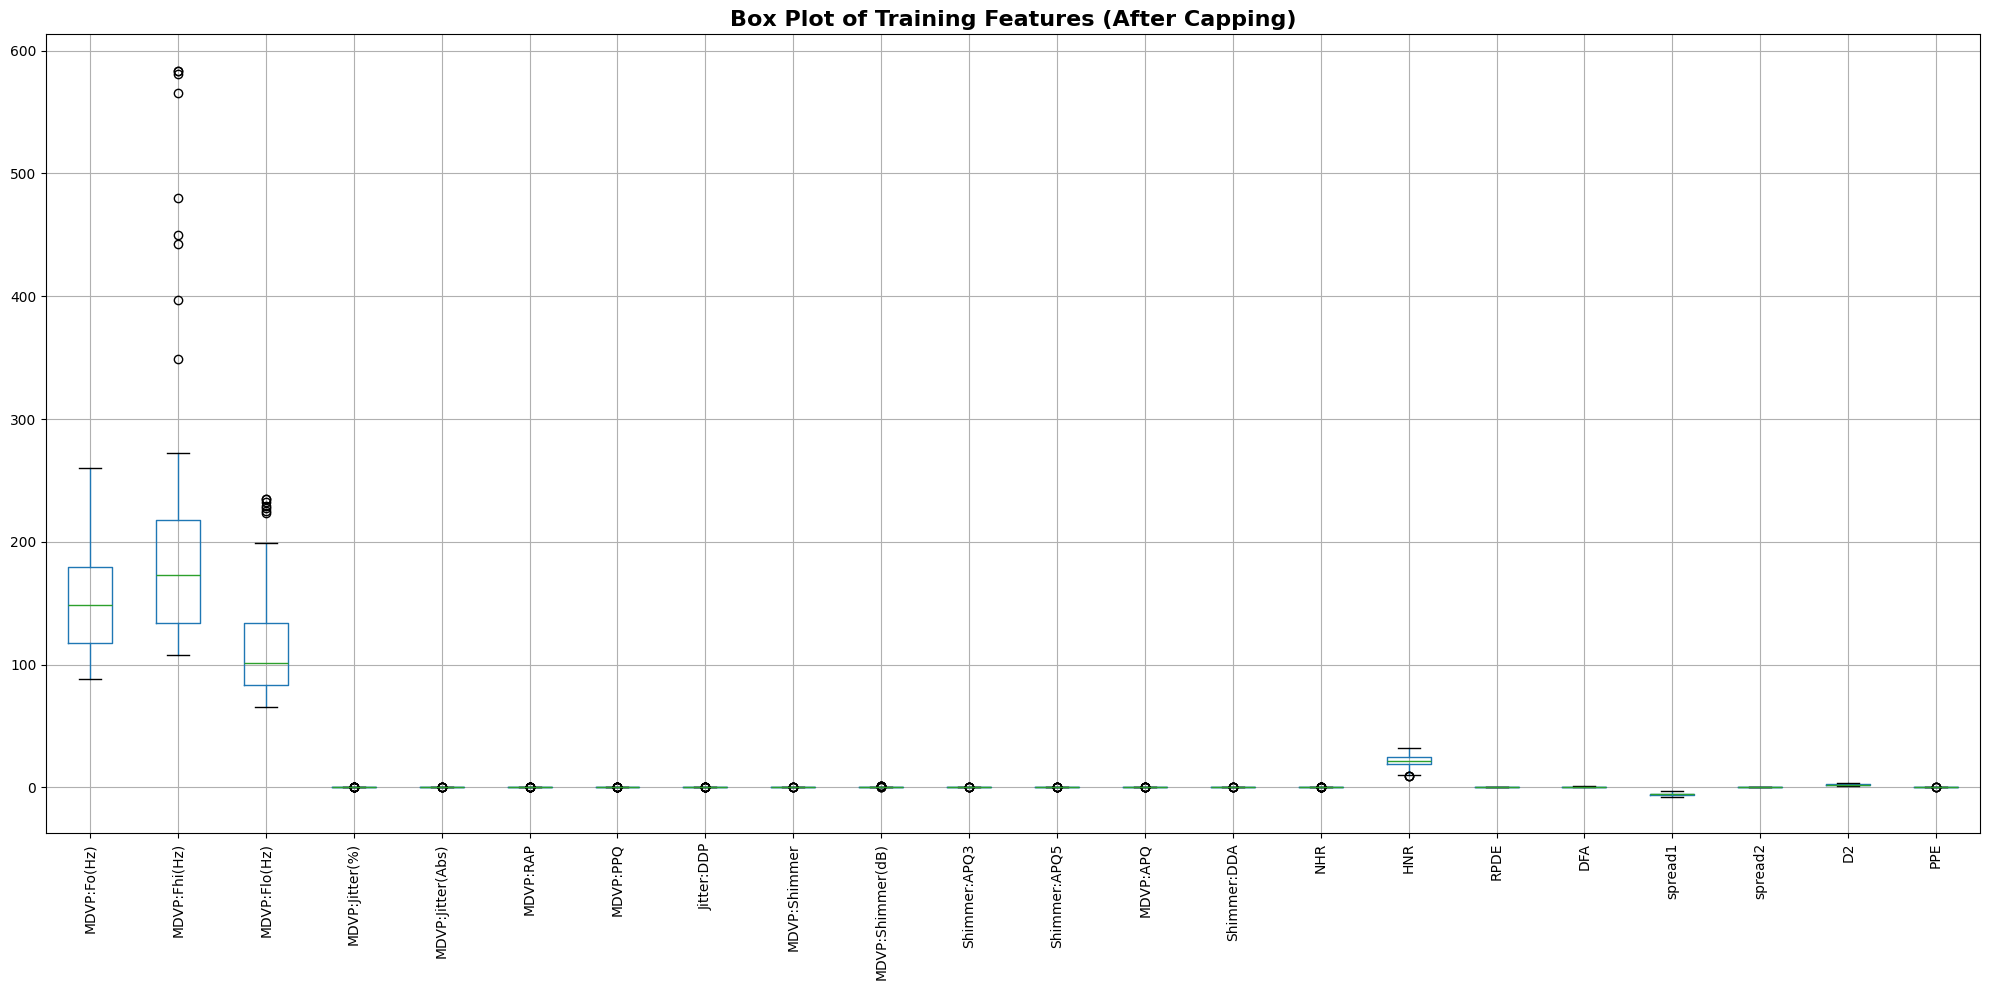

Saved: ds1_boxplot_after_capping.png


In [22]:
# ===== STEP 8: BOX PLOT AFTER CAPPING =====
plt.figure(figsize=(20, 10))
X_train_capped.boxplot(rot=90)
plt.title('Box Plot of Training Features (After Capping)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('ds1_boxplot_after_capping.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ds1_boxplot_after_capping.png')

In [24]:
# ===== STEP 9: NORMALIZE ALL FEATURES =====
print('='*80)
print('STEP 9: NORMALIZING ALL FEATURES (MinMaxScaler)')
print('='*80)
print('Scaler is fitted on training data only, then applied to both.')
print()

scaler = MinMaxScaler()

# Fit on training data only
X_train_normalized = scaler.fit_transform(X_train_capped)

# Apply same scaler to test (no re-fitting)
X_test_normalized = scaler.transform(X_test_capped)

# Convert back to dataframes
X_train_final = pd.DataFrame(X_train_normalized, columns=X_train_capped.columns, index=X_train_capped.index)
X_test_final = pd.DataFrame(X_test_normalized, columns=X_test_capped.columns, index=X_test_capped.index)

print(f'Training features normalized: {X_train_final.shape}')
print(f'Test features normalized:     {X_test_final.shape}')
print(f'\nValue range check (should be 0 to 1):')
for col in X_train_final.columns[:3]:
    print(f'  {col}: min={X_train_final[col].min():.3f}, max={X_train_final[col].max():.3f}')

STEP 9: NORMALIZING ALL FEATURES (MinMaxScaler)
Scaler is fitted on training data only, then applied to both.

Training features normalized: (156, 22)
Test features normalized:     (39, 22)

Value range check (should be 0 to 1):
  MDVP:Fo(Hz): min=0.000, max=1.000
  MDVP:Fhi(Hz): min=0.000, max=1.000
  MDVP:Flo(Hz): min=0.000, max=1.000


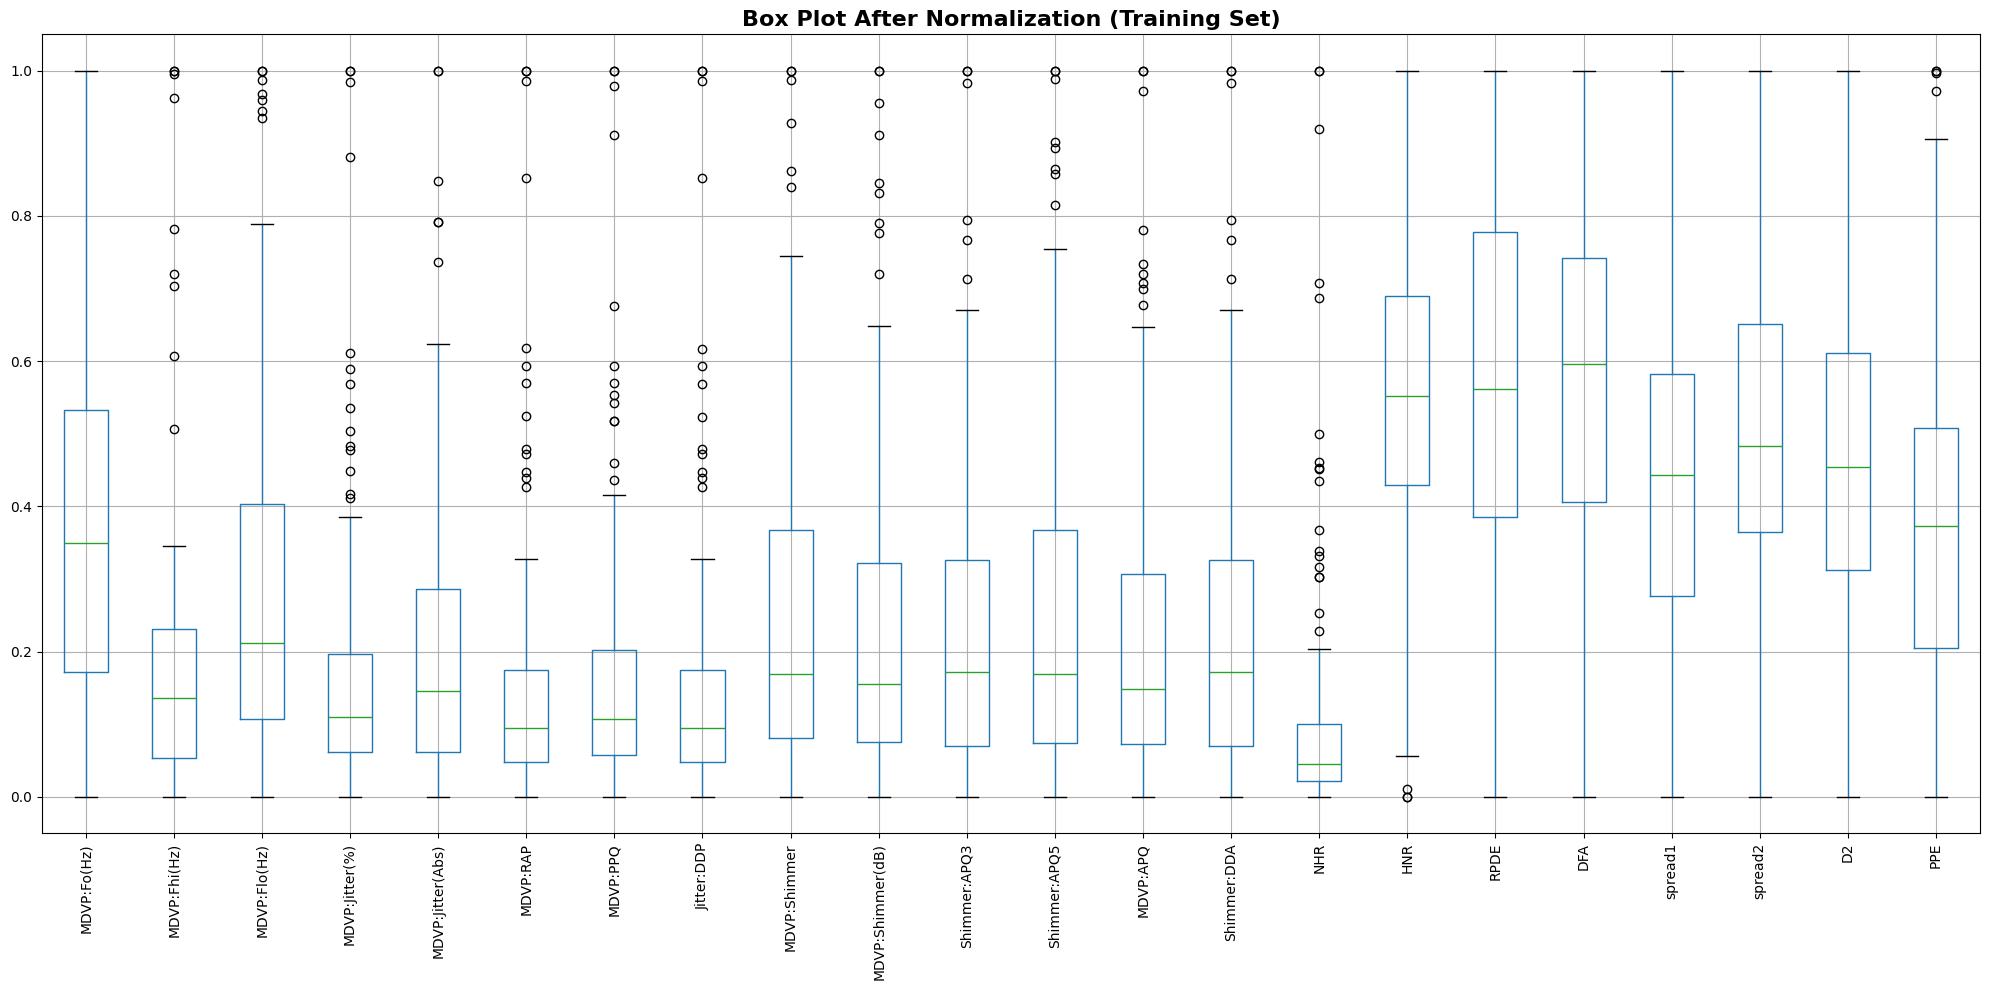

Saved: ds1_boxplot_after_normalization.png


In [25]:
# ===== STEP 10: FINAL BOX PLOT AFTER NORMALIZATION =====
plt.figure(figsize=(20, 10))
X_train_final.boxplot(rot=90)
plt.title('Box Plot After Normalization (Training Set)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('ds1_boxplot_after_normalization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ds1_boxplot_after_normalization.png')

In [27]:
# ===== STEP 11: SAVE FINAL DATASETS =====
print('='*80)
print('STEP 11: SAVING FINAL PREPROCESSED DATASETS')
print('='*80)

# Save train and test separately — keeping target separate from features
train_final = pd.concat([X_train_final.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
test_final  = pd.concat([X_test_final.reset_index(drop=True),  y_test.reset_index(drop=True)],  axis=1)

train_final.to_csv('ds1_train_preprocessed.csv', index=False)
test_final.to_csv('ds1_test_preprocessed.csv', index=False)

print(f'Train set saved: {train_final.shape}  -> ds1_train_preprocessed.csv')
print(f'Test set saved:  {test_final.shape}   -> ds1_test_preprocessed.csv')
print()
print('PREPROCESSING COMPLETE FOR DATASET 01')
print('Pipeline: Cap Outliers (1st/99th pct) -> Normalize All Features [0,1]')

STEP 11: SAVING FINAL PREPROCESSED DATASETS
Train set saved: (156, 23)  -> ds1_train_preprocessed.csv
Test set saved:  (39, 23)   -> ds1_test_preprocessed.csv

PREPROCESSING COMPLETE FOR DATASET 01
Pipeline: Cap Outliers (1st/99th pct) -> Normalize All Features [0,1]


In [28]:
from google.colab import files
files.download('ds1_train_preprocessed.csv')
files.download('ds1_test_preprocessed.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# DATASET 02 — Parkinson's Telemonitoring Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print('='*80)
print('DATASET 02: PARKINSON\'S TELEMONITORING DATA')
print('='*80)

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/telemonitoring/parkinsons_updrs.data'
df2 = pd.read_csv(url)

print(f'Dataset loaded: {df2.shape[0]} rows, {df2.shape[1]} columns')
print(f'Columns: {list(df2.columns)}')

DATASET 02: PARKINSON'S TELEMONITORING DATA
Dataset loaded: 5875 rows, 22 columns
Columns: ['subject#', 'age', 'sex', 'test_time', 'motor_UPDRS', 'total_UPDRS', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']


In [ ]:
# ===== STEP 1: CONVERT CATEGORICAL TO NUMERICAL =====
print('='*80)
print('STEP 1: CHECKING CATEGORICAL FEATURES')
print('='*80)

categorical_cols = df2.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns: {categorical_cols}')

print(f'Unique values in sex: {df2["sex"].unique()}  (already numerical)')

# Drop identifier
df2 = df2.drop('subject#', axis=1)
print('Dropped subject# (identifier)')
print(f'Remaining columns: {list(df2.columns)}')

STEP 1: CHECKING CATEGORICAL FEATURES
Categorical columns: []
Unique values in sex: [0 1]  (already numerical)
Dropped subject# (identifier)
Remaining columns: ['age', 'sex', 'test_time', 'motor_UPDRS', 'total_UPDRS', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']


In [ ]:
# ===== STEP 2: HANDLE MISSING VALUES =====
print('='*80)
print('STEP 2: HANDLING MISSING VALUES')
print('='*80)

null_counts = df2.isnull().sum()
null_cols = null_counts[null_counts > 0]

if len(null_cols) > 0:
    for col in null_cols.index:
        median_val = df2[col].median()
        df2[col] = df2[col].fillna(median_val)
        print(f'  {col}: replaced {null_cols[col]} nulls with median {median_val:.4f}')
else:
    print('No null values found')

STEP 2: HANDLING MISSING VALUES
No null values found


In [ ]:
# ===== STEP 3: SEPARATE FEATURES AND TARGETS =====
print('='*80)
print('STEP 3: SEPARATING FEATURES AND TARGETS')
print('='*80)
print('NOTE: motor_UPDRS and total_UPDRS are TARGET columns.')
print('They must NOT be scaled along with features.')
print()

# This dataset has two regression targets
target_cols = ['motor_UPDRS', 'total_UPDRS']
feature_cols = [c for c in df2.columns if c not in target_cols]

features2 = df2[feature_cols]
targets2  = df2[target_cols]

print(f'Features: {features2.shape}  ->  {feature_cols}')
print(f'Targets:  {targets2.shape}   ->  {target_cols}')
print(f'\nTarget ranges:')
print(f'  motor_UPDRS: {targets2["motor_UPDRS"].min():.2f} to {targets2["motor_UPDRS"].max():.2f}')
print(f'  total_UPDRS: {targets2["total_UPDRS"].min():.2f} to {targets2["total_UPDRS"].max():.2f}')

STEP 3: SEPARATING FEATURES AND TARGETS
NOTE: motor_UPDRS and total_UPDRS are TARGET columns.
They must NOT be scaled along with features.

Features: (5875, 19)  ->  ['age', 'sex', 'test_time', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']
Targets:  (5875, 2)   ->  ['motor_UPDRS', 'total_UPDRS']

Target ranges:
  motor_UPDRS: 5.04 to 39.51
  total_UPDRS: 7.00 to 54.99


In [ ]:
# ===== STEP 4: TRAIN/TEST SPLIT BEFORE SCALING =====
print('='*80)
print('STEP 4: TRAIN/TEST SPLIT (BEFORE SCALING)')
print('='*80)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    features2, targets2,
    test_size=0.2,
    random_state=42
)

print(f'Training set:  {X2_train.shape}')
print(f'Test set:      {X2_test.shape}')

STEP 4: TRAIN/TEST SPLIT (BEFORE SCALING)
Training set:  (4700, 19)
Test set:      (1175, 19)


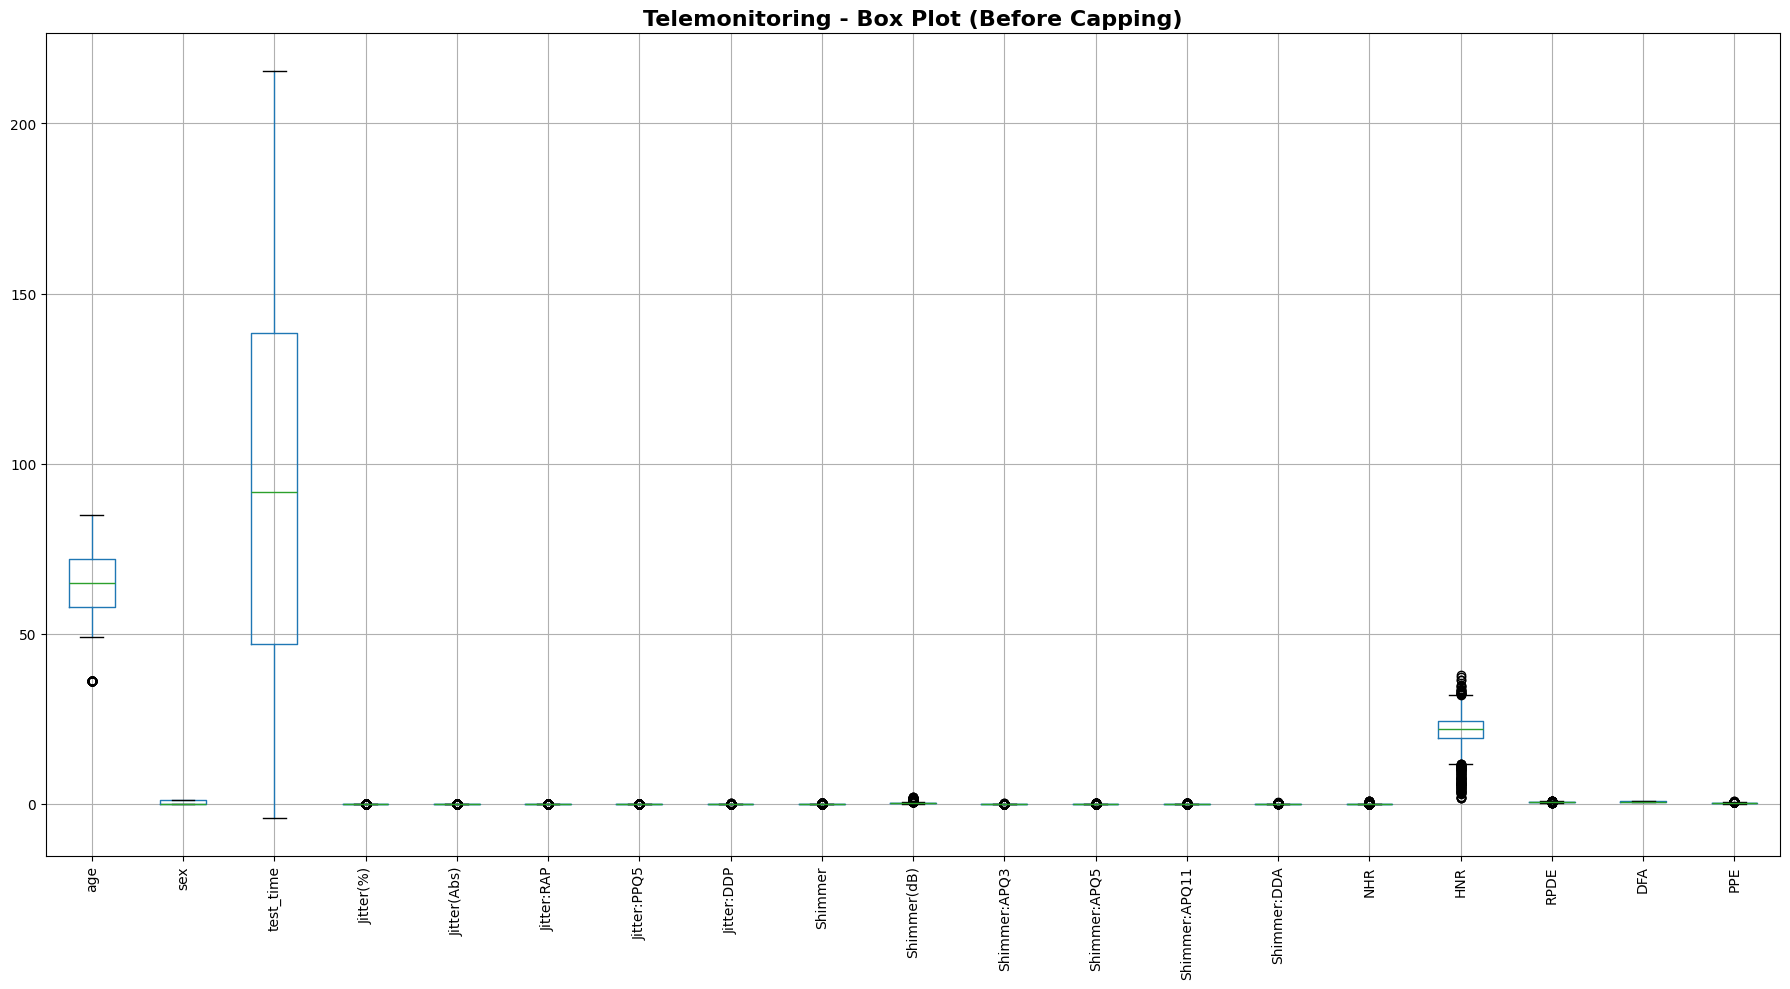

Saved: ds2_boxplot_before.png


In [ ]:
# ===== STEP 5: VISUALIZE OUTLIERS BEFORE TREATMENT =====
plt.figure(figsize=(18, 10))
X2_train.boxplot(rot=90)
plt.title('Telemonitoring - Box Plot (Before Capping)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('ds2_boxplot_before.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ds2_boxplot_before.png')

In [ ]:
# ===== STEP 6: DETECT OUTLIER FEATURES =====
print('='*80)
print('STEP 6: DETECTING OUTLIER FEATURES')
print('='*80)

def identify_outlier_features(dataframe, threshold=1.5):
    features_with_outliers = []
    for col in dataframe.columns:
        if dataframe[col].dtype in ['int64', 'float64']:
            Q1 = dataframe[col].quantile(0.25)
            Q3 = dataframe[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - threshold * IQR
            upper = Q3 + threshold * IQR
            outlier_count = ((dataframe[col] < lower) | (dataframe[col] > upper)).sum()
            if outlier_count > 0:
                features_with_outliers.append((col, outlier_count))
    return [col for col, _ in features_with_outliers]

outlier_features2 = identify_outlier_features(X2_train)
print(f'Features with outliers: {len(outlier_features2)}')
print(outlier_features2)

STEP 6: DETECTING OUTLIER FEATURES
Features with outliers: 16
['age', 'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'PPE']


In [ ]:
# ===== STEP 7: CAP OUTLIERS =====
print('='*80)
print('STEP 7: CAPPING OUTLIERS (1st/99th PERCENTILE)')
print('='*80)

def cap_outliers(train_df, test_df, columns, lower_pct=1, upper_pct=99):
    train_capped = train_df.copy()
    test_capped = test_df.copy()
    cap_values = {}
    for col in columns:
        lower = train_df[col].quantile(lower_pct / 100)
        upper = train_df[col].quantile(upper_pct / 100)
        cap_values[col] = (lower, upper)
        train_capped[col] = train_df[col].clip(lower, upper)
        test_capped[col] = test_df[col].clip(lower, upper)
    return train_capped, test_capped, cap_values

X2_train_capped, X2_test_capped, cap_values2 = cap_outliers(
    X2_train, X2_test, outlier_features2
)

print(f'Capping applied to {len(outlier_features2)} features')

STEP 7: CAPPING OUTLIERS (1st/99th PERCENTILE)
Capping applied to 16 features


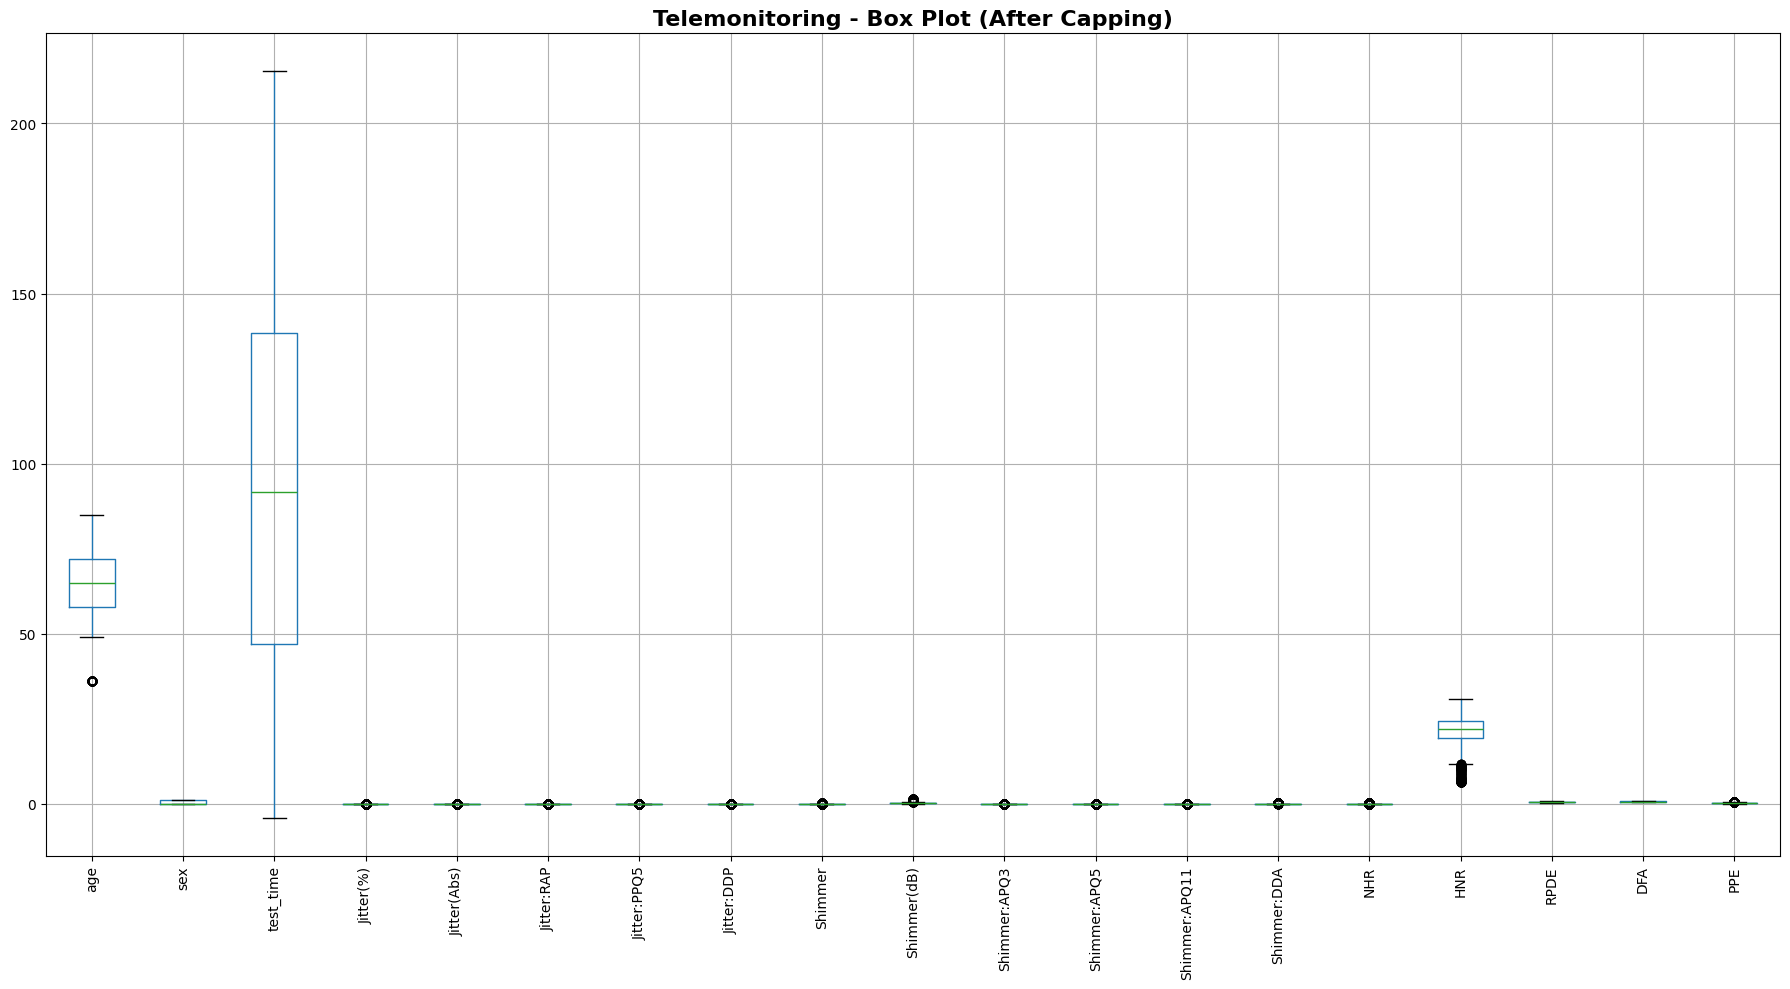

Saved: ds2_boxplot_after_capping.png


In [ ]:
# ===== STEP 8: BOX PLOT AFTER CAPPING =====
plt.figure(figsize=(18, 10))
X2_train_capped.boxplot(rot=90)
plt.title('Telemonitoring - Box Plot (After Capping)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('ds2_boxplot_after_capping.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ds2_boxplot_after_capping.png')

In [ ]:
# ===== STEP 9: NORMALIZE ALL FEATURES =====
print('='*80)
print('STEP 9: NORMALIZING ALL FEATURES')
print('='*80)

scaler2 = MinMaxScaler()

X2_train_normalized = scaler2.fit_transform(X2_train_capped)
X2_test_normalized  = scaler2.transform(X2_test_capped)  # same scaler, no refit

X2_train_final = pd.DataFrame(X2_train_normalized, columns=X2_train_capped.columns, index=X2_train_capped.index)
X2_test_final  = pd.DataFrame(X2_test_normalized,  columns=X2_test_capped.columns,  index=X2_test_capped.index)

print(f'Train normalized: {X2_train_final.shape}')
print(f'Test normalized:  {X2_test_final.shape}')

STEP 9: NORMALIZING ALL FEATURES
Train normalized: (4700, 19)
Test normalized:  (1175, 19)


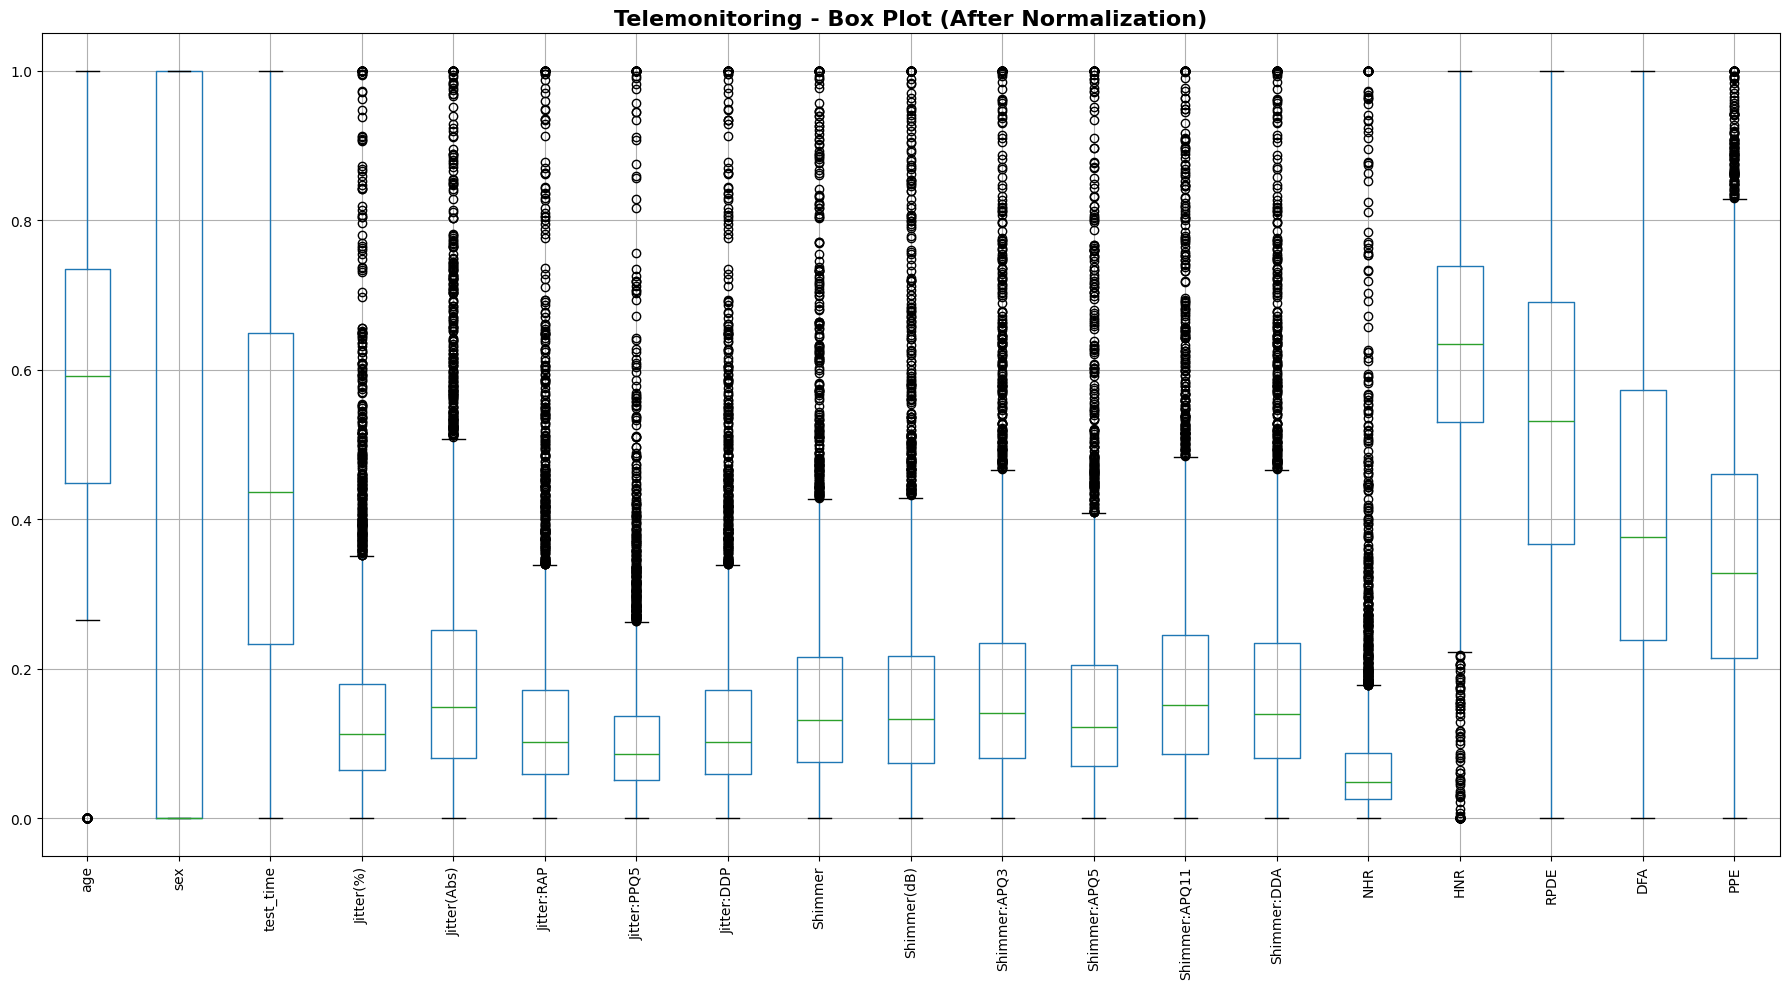

Saved: ds2_boxplot_after_normalization.png


In [ ]:
# ===== STEP 10: FINAL BOX PLOT =====
plt.figure(figsize=(18, 10))
X2_train_final.boxplot(rot=90)
plt.title('Telemonitoring - Box Plot (After Normalization)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('ds2_boxplot_after_normalization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ds2_boxplot_after_normalization.png')

In [ ]:
# ===== STEP 11: SAVE FINAL DATASETS =====
print('='*80)
print('STEP 11: SAVING FINAL PREPROCESSED DATASETS')
print('='*80)

train2_final = pd.concat([
    X2_train_final.reset_index(drop=True),
    y2_train.reset_index(drop=True)
], axis=1)

test2_final = pd.concat([
    X2_test_final.reset_index(drop=True),
    y2_test.reset_index(drop=True)
], axis=1)

train2_final.to_csv('ds2_train_preprocessed.csv', index=False)
test2_final.to_csv('ds2_test_preprocessed.csv', index=False)

print(f'Train saved: {train2_final.shape}  -> ds2_train_preprocessed.csv')
print(f'Test saved:  {test2_final.shape}   -> ds2_test_preprocessed.csv')
print()
print('PREPROCESSING COMPLETE FOR DATASET 02')

STEP 11: SAVING FINAL PREPROCESSED DATASETS
Train saved: (4700, 21)  -> ds2_train_preprocessed.csv
Test saved:  (1175, 21)   -> ds2_test_preprocessed.csv

PREPROCESSING COMPLETE FOR DATASET 02


In [ ]:
from google.colab import files
files.download('ds2_train_preprocessed.csv')
files.download('ds2_test_preprocessed.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# DATASET 03 — Oxford Parkinson's Disease Detection

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print('='*80)
print('DATASET 03: OXFORD PARKINSON\'S DISEASE DETECTION')
print('='*80)

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons.data'
df3 = pd.read_csv(url)

print(f'Dataset loaded: {df3.shape[0]} rows, {df3.shape[1]} columns')
print(f'Columns: {list(df3.columns)}')

DATASET 03: OXFORD PARKINSON'S DISEASE DETECTION
Dataset loaded: 195 rows, 24 columns
Columns: ['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']


In [32]:
# ===== STEP 1: CONVERT CATEGORICAL TO NUMERICAL =====
print('='*80)
print('STEP 1: CHECKING CATEGORICAL FEATURES')
print('='*80)

categorical_cols = df3.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical columns: {categorical_cols}')

df3 = df3.drop('name', axis=1)
print('Dropped name (identifier)')
print(f'Remaining columns: {list(df3.columns)}')

STEP 1: CHECKING CATEGORICAL FEATURES
Categorical columns: ['name']
Dropped name (identifier)
Remaining columns: ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']


In [33]:
# ===== STEP 2: HANDLE MISSING VALUES =====
print('='*80)
print('STEP 2: HANDLING MISSING VALUES')
print('='*80)

null_counts = df3.isnull().sum()
null_cols = null_counts[null_counts > 0]

if len(null_cols) > 0:
    for col in null_cols.index:
        median_val = df3[col].median()
        df3[col] = df3[col].fillna(median_val)
        print(f'  {col}: replaced {null_cols[col]} nulls with median {median_val:.4f}')
else:
    print('No null values found')

STEP 2: HANDLING MISSING VALUES
No null values found


In [34]:
# ===== STEP 3: SEPARATE FEATURES AND TARGET =====
print('='*80)
print('STEP 3: SEPARATING FEATURES AND TARGET')
print('='*80)

features3 = df3.drop('status', axis=1)
target3   = df3['status']

print(f'Features shape: {features3.shape}')

# Class imbalance check
healthy    = (target3 == 0).sum()
parkinsons = (target3 == 1).sum()
total      = len(target3)
print(f'\nClass Distribution:')
print(f'  Healthy (0):     {healthy} samples ({healthy/total*100:.1f}%)')
print(f'  Parkinsons (1):  {parkinsons} samples ({parkinsons/total*100:.1f}%)')

if parkinsons/total > 0.65 or healthy/total > 0.65:
    print()
    print('  WARNING: Class imbalance detected.')
    print('  Do NOT use accuracy as your only metric.')
    print('  Use: precision, recall, F1-score, AUC-ROC')
    print('  Consider: class_weight=balanced in your classifier')

STEP 3: SEPARATING FEATURES AND TARGET
Features shape: (195, 22)

Class Distribution:
  Healthy (0):     48 samples (24.6%)
  Parkinsons (1):  147 samples (75.4%)

  Do NOT use accuracy as your only metric.
  Use: precision, recall, F1-score, AUC-ROC
  Consider: class_weight=balanced in your classifier


In [36]:
# ===== STEP 4: TRAIN/TEST SPLIT BEFORE SCALING =====
print('='*80)
print('STEP 4: TRAIN/TEST SPLIT (BEFORE SCALING)')
print('='*80)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    features3, target3,
    test_size=0.2,
    random_state=42,
    stratify=target3
)

print(f'Training set:  {X3_train.shape[0]} samples')
print(f'Test set:      {X3_test.shape[0]} samples')
print(f'\nClass distribution in training:')
print(f'  Healthy: {(y3_train==0).sum()}  |  Parkinsons: {(y3_train==1).sum()}')
print(f'Class distribution in test:')
print(f'  Healthy: {(y3_test==0).sum()}  |  Parkinsons: {(y3_test==1).sum()}')

STEP 4: TRAIN/TEST SPLIT (BEFORE SCALING)
Training set:  156 samples
Test set:      39 samples

Class distribution in training:
  Healthy: 38  |  Parkinsons: 118
Class distribution in test:
  Healthy: 10  |  Parkinsons: 29


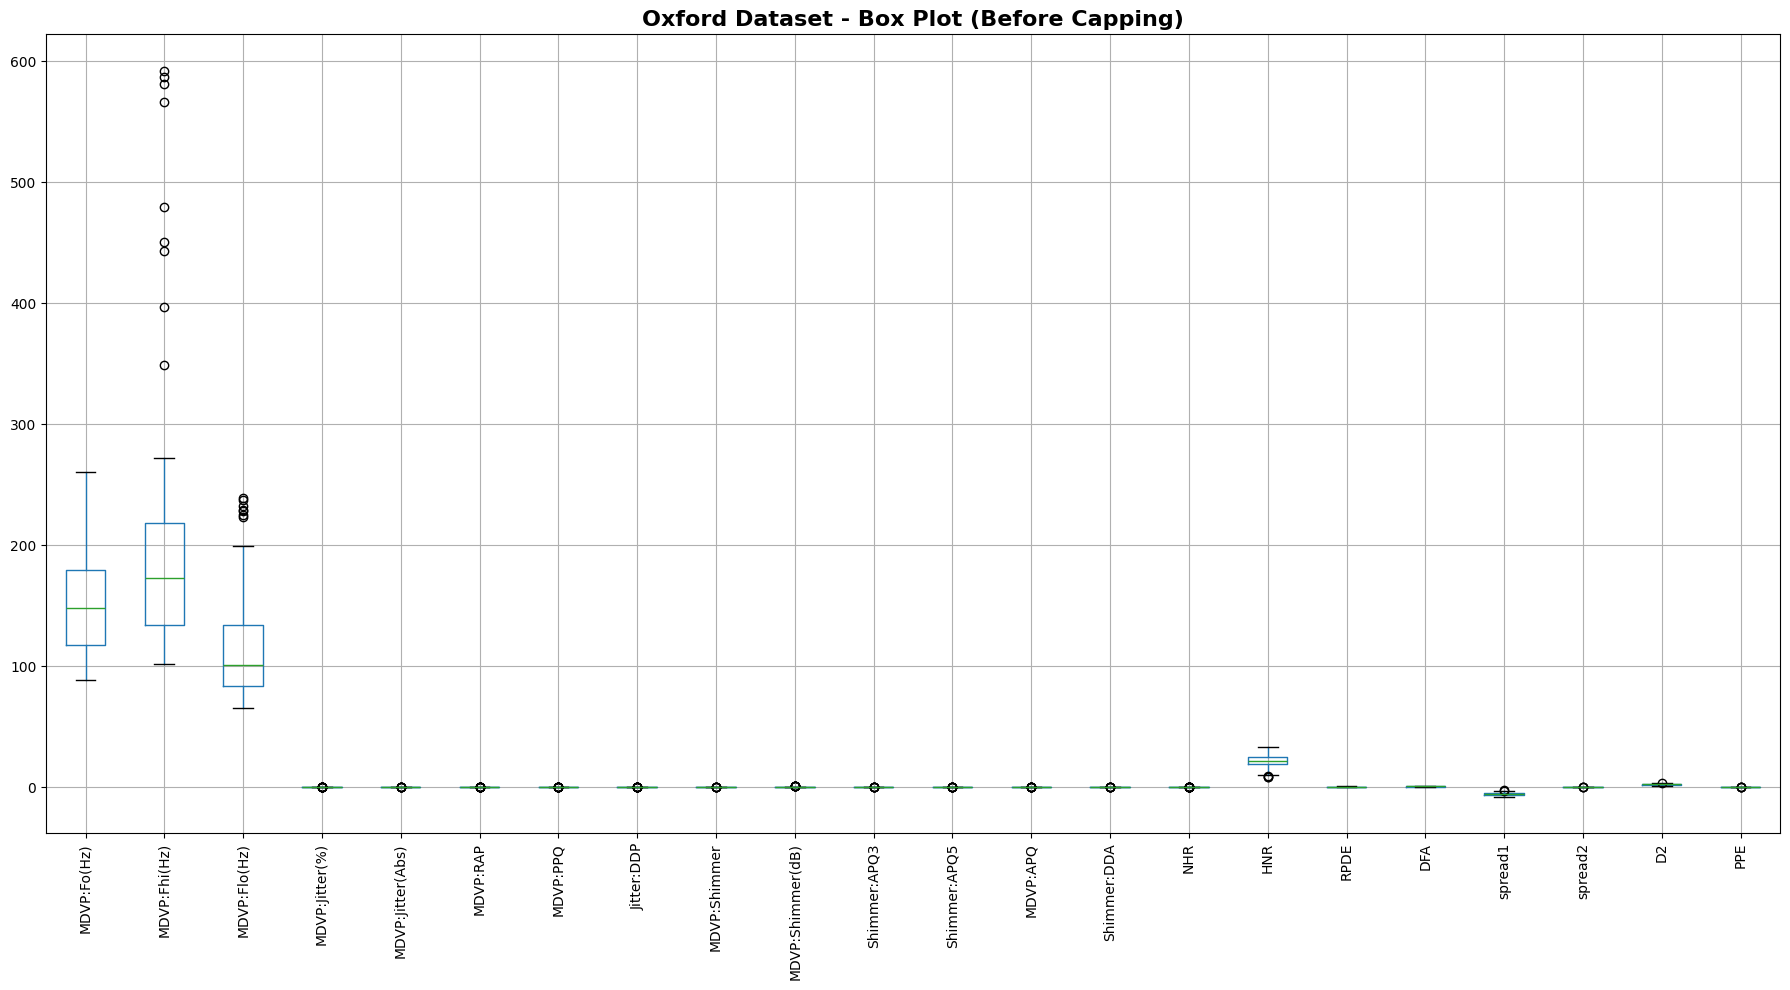

Saved: ds3_boxplot_before.png


In [37]:
# ===== STEP 5: VISUALIZE OUTLIERS BEFORE TREATMENT =====
plt.figure(figsize=(18, 10))
X3_train.boxplot(rot=90)
plt.title('Oxford Dataset - Box Plot (Before Capping)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('ds3_boxplot_before.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ds3_boxplot_before.png')

In [38]:
# ===== STEP 6: DETECT OUTLIER FEATURES =====
print('='*80)
print('STEP 6: DETECTING OUTLIER FEATURES')
print('='*80)

def identify_outlier_features(dataframe, threshold=1.5):
    features_with_outliers = []
    for col in dataframe.columns:
        if dataframe[col].dtype in ['int64', 'float64']:
            Q1 = dataframe[col].quantile(0.25)
            Q3 = dataframe[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - threshold * IQR
            upper = Q3 + threshold * IQR
            outlier_count = ((dataframe[col] < lower) | (dataframe[col] > upper)).sum()
            if outlier_count > 0:
                features_with_outliers.append((col, outlier_count))
    return [col for col, _ in features_with_outliers]

outlier_features3 = identify_outlier_features(X3_train)
print(f'Features with outliers: {len(outlier_features3)}')
print(outlier_features3)

STEP 6: DETECTING OUTLIER FEATURES
Features with outliers: 19
['MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'spread1', 'spread2', 'D2', 'PPE']


In [39]:
# ===== STEP 7: CAP OUTLIERS =====
print('='*80)
print('STEP 7: CAPPING OUTLIERS (1st/99th PERCENTILE)')
print('='*80)

def cap_outliers(train_df, test_df, columns, lower_pct=1, upper_pct=99):
    train_capped = train_df.copy()
    test_capped  = test_df.copy()
    cap_values   = {}
    for col in columns:
        lower = train_df[col].quantile(lower_pct / 100)
        upper = train_df[col].quantile(upper_pct / 100)
        cap_values[col] = (lower, upper)
        train_capped[col] = train_df[col].clip(lower, upper)
        test_capped[col]  = test_df[col].clip(lower, upper)
    return train_capped, test_capped, cap_values

X3_train_capped, X3_test_capped, cap_values3 = cap_outliers(
    X3_train, X3_test, outlier_features3
)

print(f'Capping applied to {len(outlier_features3)} features')

STEP 7: CAPPING OUTLIERS (1st/99th PERCENTILE)
Capping applied to 19 features


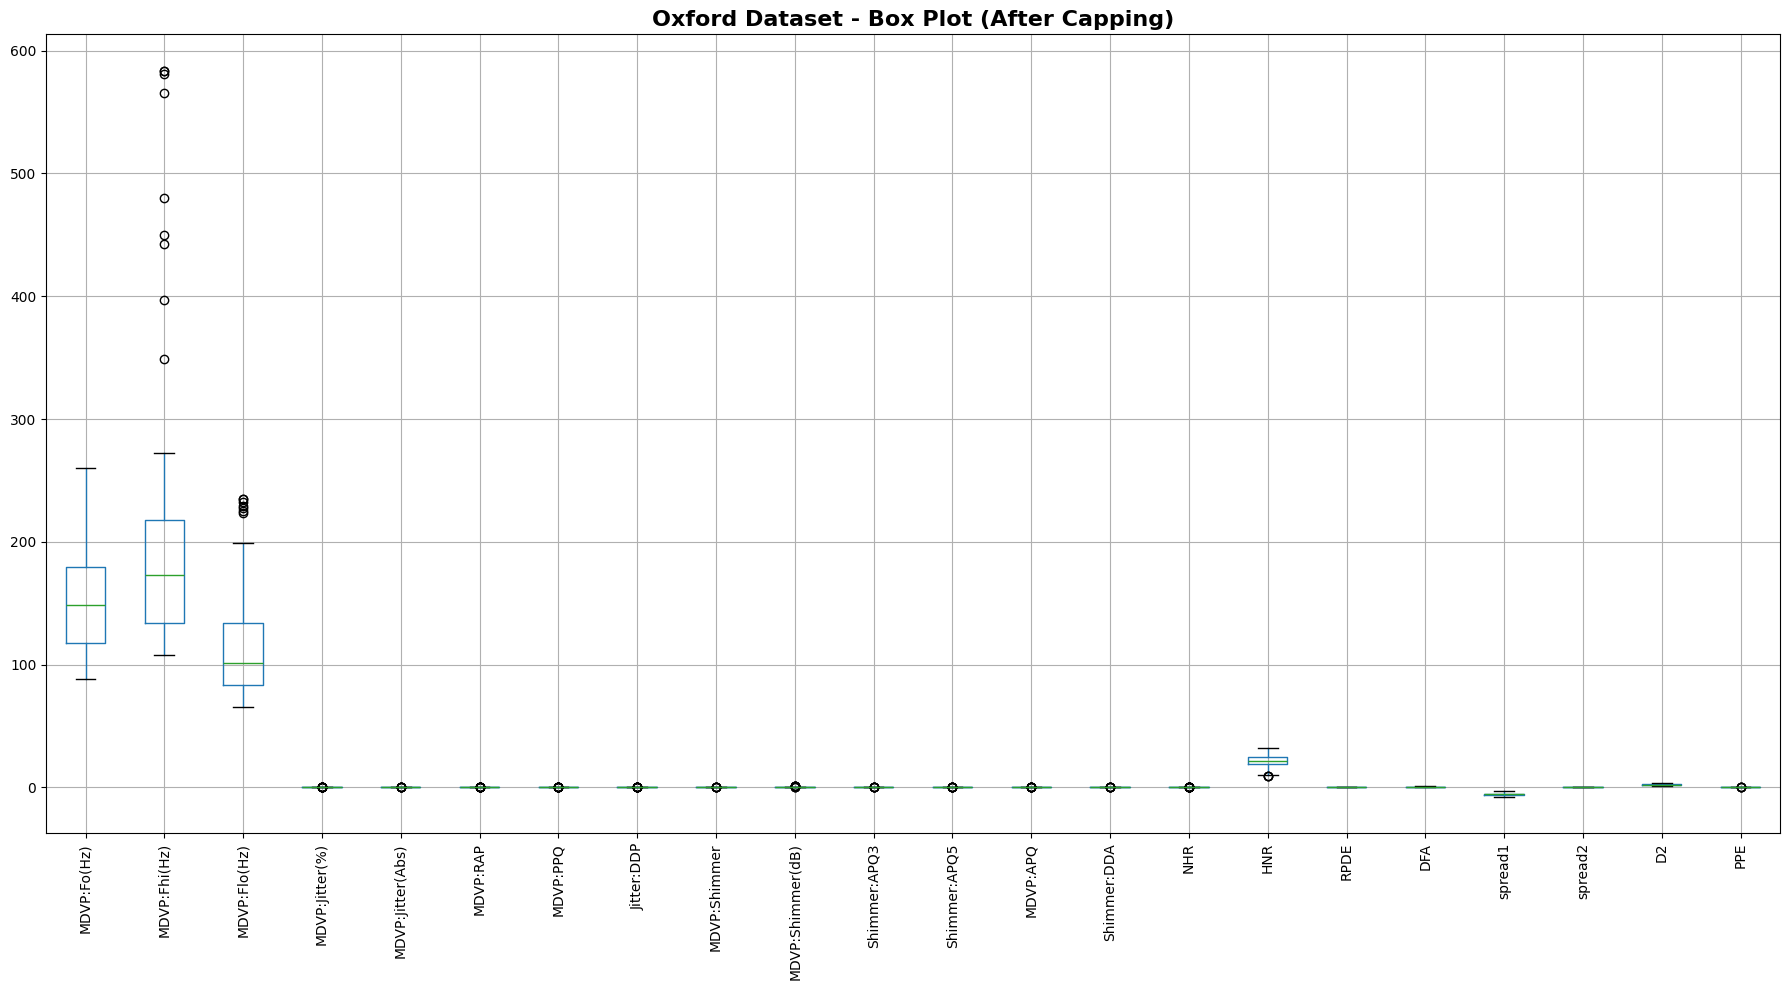

Saved: ds3_boxplot_after_capping.png


In [40]:
# ===== STEP 8: BOX PLOT AFTER CAPPING =====
plt.figure(figsize=(18, 10))
X3_train_capped.boxplot(rot=90)
plt.title('Oxford Dataset - Box Plot (After Capping)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('ds3_boxplot_after_capping.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ds3_boxplot_after_capping.png')

In [42]:
# ===== STEP 9: NORMALIZE ALL FEATURES =====
print('='*80)
print('STEP 9: NORMALIZING ALL FEATURES')
print('='*80)

scaler3 = MinMaxScaler()

if 'name' in X3_train_capped.columns:
    X3_train_capped = X3_train_capped.drop('name', axis=1)
if 'name' in X3_test_capped.columns:
    X3_test_capped = X3_test_capped.drop('name', axis=1)

X3_train_normalized = scaler3.fit_transform(X3_train_capped)
X3_test_normalized  = scaler3.transform(X3_test_capped)

X3_train_final = pd.DataFrame(X3_train_normalized, columns=X3_train_capped.columns, index=X3_train_capped.index)
X3_test_final  = pd.DataFrame(X3_test_normalized,  columns=X3_test_capped.columns,  index=X3_test_capped.index)

print(f'Train normalized: {X3_train_final.shape}')
print(f'Test normalized:  {X3_test_final.shape}')

STEP 9: NORMALIZING ALL FEATURES
Train normalized: (156, 22)
Test normalized:  (39, 22)


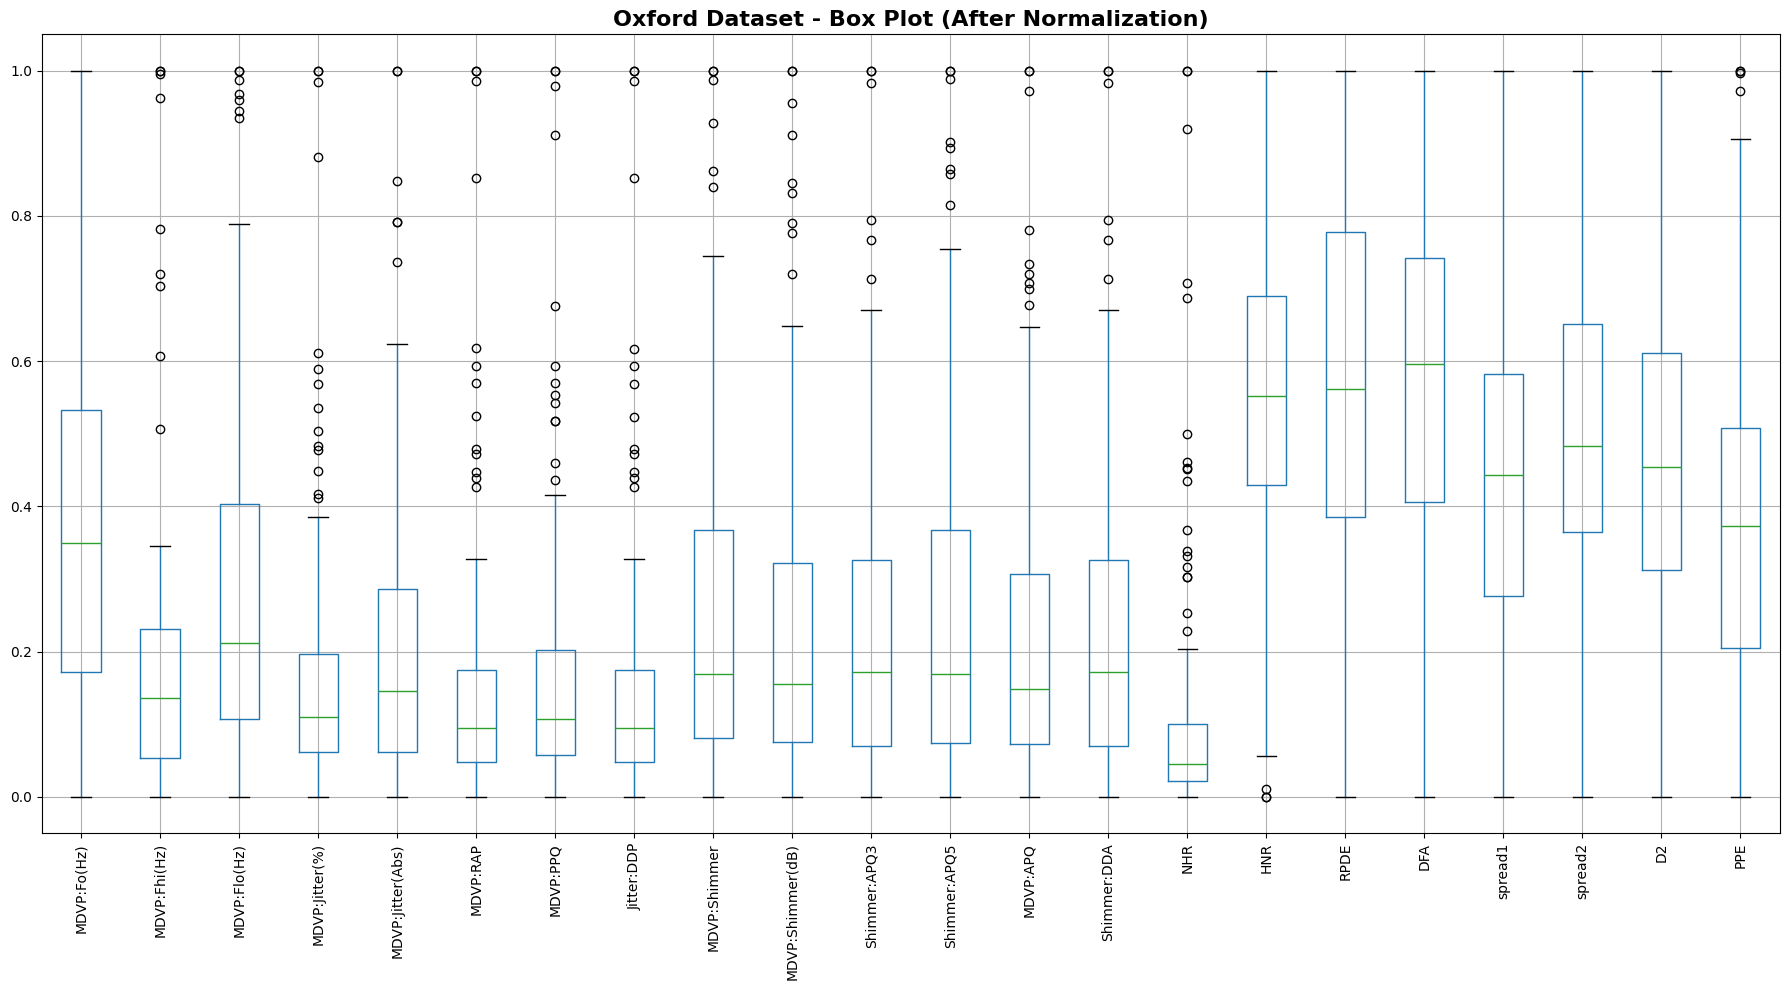

Saved: ds3_boxplot_after_normalization.png


In [43]:
# ===== STEP 10: FINAL BOX PLOT =====
plt.figure(figsize=(18, 10))
X3_train_final.boxplot(rot=90)
plt.title('Oxford Dataset - Box Plot (After Normalization)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('ds3_boxplot_after_normalization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ds3_boxplot_after_normalization.png')

In [44]:
# ===== STEP 11: SAVE FINAL DATASETS =====
print('='*80)
print('STEP 11: SAVING FINAL PREPROCESSED DATASETS')
print('='*80)

train3_final = pd.concat([
    X3_train_final.reset_index(drop=True),
    y3_train.reset_index(drop=True)
], axis=1)

test3_final = pd.concat([
    X3_test_final.reset_index(drop=True),
    y3_test.reset_index(drop=True)
], axis=1)

train3_final.to_csv('ds3_train_preprocessed.csv', index=False)
test3_final.to_csv('ds3_test_preprocessed.csv', index=False)

print(f'Train saved: {train3_final.shape}  -> ds3_train_preprocessed.csv')
print(f'Test saved:  {test3_final.shape}   -> ds3_test_preprocessed.csv')
print()
print('PREPROCESSING COMPLETE FOR DATASET 03')
print()
print('='*80)
print('ALL 3 DATASETS PREPROCESSED SUCCESSFULLY')
print('='*80)
print('Pipeline used for all datasets:')
print('  1. Drop identifier columns')
print('  2. Handle missing values (median imputation)')
print('  3. Separate features and target')
print('  4. Train/test split (stratified where applicable)')
print('  5. Detect outlier features using IQR on training data')
print('  6. Cap outliers at 1st/99th percentile (fit on train, apply to both)')
print('  7. Normalize all features [0,1] (fit on train, apply to both)')
print('  8. Save train and test sets separately')

STEP 11: SAVING FINAL PREPROCESSED DATASETS
Train saved: (156, 23)  -> ds3_train_preprocessed.csv
Test saved:  (39, 23)   -> ds3_test_preprocessed.csv

PREPROCESSING COMPLETE FOR DATASET 03

ALL 3 DATASETS PREPROCESSED SUCCESSFULLY
Pipeline used for all datasets:
  1. Drop identifier columns
  2. Handle missing values (median imputation)
  3. Separate features and target
  4. Train/test split (stratified where applicable)
  5. Detect outlier features using IQR on training data
  6. Cap outliers at 1st/99th percentile (fit on train, apply to both)
  7. Normalize all features [0,1] (fit on train, apply to both)
  8. Save train and test sets separately


In [45]:
from google.colab import files
files.download('ds3_train_preprocessed.csv')
files.download('ds3_test_preprocessed.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>